# S-Learner: Uplift Modeling

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklift.datasets import fetch_x5
from feature_extraction import UpliftFeatureExtractor
from sklift.metrics import uplift_at_k, uplift_auc_score, qini_auc_score

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [22]:
dataset = fetch_x5()
data = dataset.data

extractor = UpliftFeatureExtractor(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

features = extractor.feature_names
print(f"Создано признаков: {len(features)}")

# Добавление treatment как признак
X = df[features].copy()
X['treatment'] = df['treatment_flg'].astype(int)
y = df["target"]

print(f"Размер X: {X.shape}")
print(f"Распределение target: {y.value_counts().to_dict()}")

Создано признаков: 32
Размер X: (200039, 33)
Распределение target: {1: 124002, 0: 76037}


In [23]:
# Разделение
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X, y, df['treatment_flg'], 
    test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# Определяем колонки
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Убираем treatment из numerical_cols если он там
if 'treatment' in numerical_cols:
    numerical_cols.remove('treatment')
if 'treatment' not in categorical_cols:
    categorical_cols.append('treatment')

print(f"Числовые признаки: {len(numerical_cols)}")
print(f"Категориальные признаки: {categorical_cols}")

# Стандартизация числовых
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

# Кодирование категориальных
label_encoders = {}
X_train_cat = np.zeros((X_train.shape[0], len(categorical_cols)))
X_test_cat = np.zeros((X_test.shape[0], len(categorical_cols)))

for i, col in enumerate(categorical_cols):
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_test[col]]).astype(str)
    le.fit(combined)
    X_train_cat[:, i] = le.transform(X_train[col].astype(str))
    X_test_cat[:, i] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

print(f"После обработки: train_num={X_train_num.shape}, train_cat={X_train_cat.shape}")

Train size: (160031, 33), Test size: (40008, 33)
Числовые признаки: 26
Категориальные признаки: ['first_transaction_quarter', 'gender', 'treatment']
После обработки: train_num=(160031, 26), train_cat=(160031, 3)


In [31]:
class SLearnerNeuralNet(BaseEstimator, ClassifierMixin):
    """
    Нейросеть для S-learner с отдельными входами для числовых признаков,
    категориальных и treatment
    """
    
    def __init__(self, 
                 numerical_dim,
                 categorical_dim,
                 cat_embed_dim=4,
                 hidden_dims=[64, 32],
                 dropout=0.3,
                 lr=0.001,
                 batch_size=256,
                 epochs=50,
                 device='cpu'):
        self.numerical_dim = numerical_dim
        self.categorical_dim = categorical_dim
        self.cat_embed_dim = cat_embed_dim
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.device = device
        self.model_ = None
        self.cat_embeddings_ = None
        self.classes_ = np.array([0, 1])
    
    def fit(self, X, y):
        X, y = check_X_y(X, y, accept_sparse=False)
        
        # Разделяем на числовые, категориальные и treatment
        # Предполагаем, что treatment - последний столбец
        numerical = X[:, :self.numerical_dim]
        categorical = X[:, self.numerical_dim:self.numerical_dim + self.categorical_dim]
        treatment = X[:, -1:] if X.shape[1] > self.numerical_dim + self.categorical_dim else np.zeros((X.shape[0], 1))
        
        print(f"Размерности: numerical={numerical.shape}, categorical={categorical.shape}, treatment={treatment.shape}")
        
        # Конвертация в тензоры
        num_tensor = torch.FloatTensor(numerical).to(self.device)
        cat_tensor = torch.LongTensor(categorical).to(self.device)
        treat_tensor = torch.FloatTensor(treatment).to(self.device)
        y_tensor = torch.FloatTensor(y).reshape(-1, 1).to(self.device)
        
        # Эмбеддинги для категориальных
        self.cat_embeddings_ = nn.ModuleList([
            nn.Embedding(200, self.cat_embed_dim).to(self.device) for _ in range(self.categorical_dim)
        ])
        
        # Расчет входной размерности
        cat_embed_total = self.categorical_dim * self.cat_embed_dim
        total_input_dim = self.numerical_dim + cat_embed_total + 1  # +1 для treatment
        print(f"Total input dimension: {total_input_dim}")
        
        # Строим сеть с правильной размерностью
        layers = []
        prev_dim = total_input_dim
        for h_dim in self.hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(self.dropout))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        
        self.model_ = nn.Sequential(*layers).to(self.device)
        
        optimizer = optim.Adam(list(self.model_.parameters()) + list(self.cat_embeddings_.parameters()), lr=self.lr)
        criterion = nn.BCELoss()
        
        dataset = TensorDataset(num_tensor, cat_tensor, treat_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model_.train()
        for epoch in range(self.epochs):
            total_loss = 0
            for batch_num, batch_cat, batch_treat, batch_y in dataloader:
                optimizer.zero_grad()
                
                # Эмбеддинги категориальных
                cat_embedded = []
                for i, emb in enumerate(self.cat_embeddings_):
                    cat_embedded.append(emb(batch_cat[:, i]))
                cat_concat = torch.cat(cat_embedded, dim=1)
                
                # Объединяем все признаки
                combined = torch.cat([batch_num, cat_concat, batch_treat], dim=1)
                
                output = self.model_(combined)
                loss = criterion(output, batch_y)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, Loss: {total_loss/len(dataloader):.4f}")
        
        return self
    
    def predict_proba(self, X):
        check_is_fitted(self, 'model_')
        X = check_array(X, accept_sparse=False)
        
        numerical = X[:, :self.numerical_dim]
        categorical = X[:, self.numerical_dim:self.numerical_dim + self.categorical_dim]
        treatment = X[:, -1:] if X.shape[1] > self.numerical_dim + self.categorical_dim else np.zeros((X.shape[0], 1))
        
        num_tensor = torch.FloatTensor(numerical).to(self.device)
        cat_tensor = torch.LongTensor(categorical).to(self.device)
        treat_tensor = torch.FloatTensor(treatment).to(self.device)
        
        self.model_.eval()
        with torch.no_grad():
            cat_embedded = []
            for i, emb in enumerate(self.cat_embeddings_):
                cat_embedded.append(emb(cat_tensor[:, i]))
            cat_concat = torch.cat(cat_embedded, dim=1)
            combined = torch.cat([num_tensor, cat_concat, treat_tensor], dim=1)
            predictions = self.model_(combined).cpu().numpy()
        
        return np.hstack([1 - predictions, predictions])
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

In [32]:
X_train_combined = np.hstack([X_train_num, X_train_cat])
X_test_combined = np.hstack([X_test_num, X_test_cat])

print(f"X_train_combined shape: {X_train_combined.shape}")
print(f"X_test_combined shape: {X_test_combined.shape}")

X_train_combined shape: (160031, 29)
X_test_combined shape: (40008, 29)


In [33]:
s_learner_nn = SLearnerNeuralNet(
    numerical_dim=X_train_num.shape[1],
    categorical_dim=X_train_cat.shape[1],
    cat_embed_dim=4,
    hidden_dims=[64, 32],
    dropout=0.2,
    lr=0.0005,
    batch_size=256,
    epochs=30,
    device=device
)

print("Обучение нейросетевого S-learner...")
s_learner_nn.fit(X_train_combined, y_train)

# Предсказания для treatment=1 и treatment=0
print("Предсказание...")

# Меняем последний столбец (treatment) на 1 и 0
X_test_t1 = X_test_combined.copy()
X_test_t0 = X_test_combined.copy()
X_test_t1[:, -1] = 1
X_test_t0[:, -1] = 0

probs_t1 = s_learner_nn.predict_proba(X_test_t1)[:, 1]
probs_t0 = s_learner_nn.predict_proba(X_test_t0)[:, 1]
uplift_scores = probs_t1 - probs_t0

# Метрики
auuc_score = uplift_auc_score(y_true=y_test, uplift=uplift_scores, treatment=treatment_test)

print(f"Результаты S-learner Neural Network:")
print(f"AUUC: {auuc_score:.6f}")
print(f"Средний uplift: {uplift_scores.mean():.6f}")
print(f"Min uplift: {uplift_scores.min():.6f}")
print(f"Max uplift: {uplift_scores.max():.6f}")

for k in [0.1, 0.2, 0.3]:
    u_k = uplift_at_k(y_true=y_test, uplift=uplift_scores, treatment=treatment_test, strategy="overall", k=k)
    print(f"Uplift@{int(k*100)}%: {u_k:.6f}")

Обучение нейросетевого S-learner...
Размерности: numerical=(160031, 26), categorical=(160031, 3), treatment=(160031, 1)
Total input dimension: 39
Epoch 10/30, Loss: 0.5563
Epoch 20/30, Loss: 0.5544
Epoch 30/30, Loss: 0.5542
Предсказание...
Результаты S-learner Neural Network:
AUUC: 0.027763
Средний uplift: 0.025435
Min uplift: -0.055547
Max uplift: 0.243837
Uplift@10%: 0.093556
Uplift@20%: 0.074894
Uplift@30%: 0.070918


In [34]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold

def objective(trial):
    params = {
        'hidden_dims': trial.suggest_categorical('hidden_dims', [[64, 32], [128, 64], [128, 64, 32], [256, 128, 64]]),
        'dropout': trial.suggest_float('dropout', 0.1, 0.4),
        'lr': trial.suggest_float('lr', 1e-4, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),
        'epochs': trial.suggest_int('epochs', 30, 80, step=10),
        'cat_embed_dim': trial.suggest_int('cat_embed_dim', 4, 12, step=2),
    }
    
    # Кросс-валидация
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_combined, y_train)):
        X_tr, X_val = X_train_combined[train_idx], X_train_combined[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        t_tr, t_val = treatment_train.iloc[train_idx], treatment_train.iloc[val_idx]
        
        model = SLearnerNeuralNet(
            numerical_dim=X_train_num.shape[1],
            categorical_dim=X_train_cat.shape[1],
            cat_embed_dim=params['cat_embed_dim'],
            hidden_dims=params['hidden_dims'],
            dropout=params['dropout'],
            lr=params['lr'],
            batch_size=params['batch_size'],
            epochs=params['epochs'],
            device=device
        )
        
        try:
            model.fit(X_tr, y_tr)
            
            # Uplift на валидации
            X_val_t1 = X_val.copy()
            X_val_t0 = X_val.copy()
            X_val_t1[:, -1] = 1
            X_val_t0[:, -1] = 0
            
            prob_t1 = model.predict_proba(X_val_t1)[:, 1]
            prob_t0 = model.predict_proba(X_val_t0)[:, 1]
            uplift_val = prob_t1 - prob_t0
            
            score = uplift_auc_score(y_true=y_val, uplift=uplift_val, treatment=t_val)
            scores.append(score)
            print(f"Fold {fold+1}: AUUC={score:.6f}")
        except Exception as e:
            print(f"Error in fold {fold+1}: {e}")
            return float('-inf')
    
    mean_score = float(np.mean(scores))
    print(f"Trial {trial.number}: Mean AUUC={mean_score:.6f}, params={params}")
    return mean_score

In [35]:
study = optuna.create_study(direction="maximize", study_name="s_learner_nn_auuc")
study.optimize(objective, n_trials=15)

print(f"\nЛучший AUUC по CV: {study.best_value:.6f}")
print(f"Лучшие параметры: {study.best_params}")

Размерности: numerical=(106687, 26), categorical=(106687, 3), treatment=(106687, 1)
Total input dimension: 51
Epoch 10/40, Loss: 0.5591
Epoch 20/40, Loss: 0.5570
Epoch 30/40, Loss: 0.5555
Epoch 40/40, Loss: 0.5552
Fold 1: AUUC=0.019720
Размерности: numerical=(106687, 26), categorical=(106687, 3), treatment=(106687, 1)
Total input dimension: 51
Epoch 10/40, Loss: 0.5581
Epoch 20/40, Loss: 0.5566
Epoch 30/40, Loss: 0.5560
Epoch 40/40, Loss: 0.5554
Fold 2: AUUC=0.019079
Размерности: numerical=(106688, 26), categorical=(106688, 3), treatment=(106688, 1)
Total input dimension: 51
Epoch 10/40, Loss: 0.5579
Epoch 20/40, Loss: 0.5562
Epoch 30/40, Loss: 0.5556
Epoch 40/40, Loss: 0.5545
Fold 3: AUUC=0.017018
Trial 0: Mean AUUC=0.018606, params={'hidden_dims': [64, 32], 'dropout': 0.30449831446404446, 'lr': 0.0008604806484085564, 'batch_size': 512, 'epochs': 40, 'cat_embed_dim': 8}
Размерности: numerical=(106687, 26), categorical=(106687, 3), treatment=(106687, 1)
Total input dimension: 39
Epoch 

In [42]:
best_params = study.best_params
print(f"Обучение финальной модели с параметрами: {best_params}")

final_s_learner = SLearnerNeuralNet(
    numerical_dim=X_train_num.shape[1],
    categorical_dim=X_train_cat.shape[1],
    cat_embed_dim=best_params['cat_embed_dim'],
    hidden_dims=best_params['hidden_dims'],
    dropout=best_params['dropout'],
    lr=best_params['lr'],
    batch_size=best_params['batch_size'],
    epochs=best_params['epochs'],
    device=device
)

final_s_learner.fit(X_train_combined, y_train)

# Предсказания на тесте
X_test_t1 = X_test_combined.copy()
X_test_t0 = X_test_combined.copy()
X_test_t1[:, -1] = 1
X_test_t0[:, -1] = 0

probs_t1 = final_s_learner.predict_proba(X_test_t1)[:, 1]
probs_t0 = final_s_learner.predict_proba(X_test_t0)[:, 1]
uplift_scores = probs_t1 - probs_t0

# Метрики
auuc_score = uplift_auc_score(y_true=y_test, uplift=uplift_scores, treatment=treatment_test)
qini_score = qini_auc_score(y_true=y_test, uplift=uplift_scores, treatment=treatment_test)

print(f"Финальные результаты S-learner Neural Network:")
print(f"AUUC: {auuc_score:.6f}")
print(f"Qini: {qini_score:.6f}")
print(f"Средний uplift: {uplift_scores.mean():.6f}")
print(f"Min uplift: {uplift_scores.min():.6f}")
print(f"Max uplift: {uplift_scores.max():.6f}")

for k in [0.1, 0.2, 0.3, 0.5]:
    u_k = uplift_at_k(y_true=y_test, uplift=uplift_scores, treatment=treatment_test, strategy="overall", k=k)
    print(f"Uplift@{int(k*100)}%: {u_k:.6f}")

Обучение финальной модели с параметрами: {'hidden_dims': [64, 32], 'dropout': 0.20295116715006706, 'lr': 0.0009865977951798554, 'batch_size': 512, 'epochs': 30, 'cat_embed_dim': 8}
Размерности: numerical=(160031, 26), categorical=(160031, 3), treatment=(160031, 1)
Total input dimension: 51
Epoch 10/30, Loss: 0.5554
Epoch 20/30, Loss: 0.5538
Epoch 30/30, Loss: 0.5535
Финальные результаты S-learner Neural Network:
AUUC: 0.017479
Qini: 0.011003
Средний uplift: 0.028373
Min uplift: -0.091537
Max uplift: 0.328658
Uplift@10%: 0.093705
Uplift@20%: 0.076899
Uplift@30%: 0.062982
Uplift@50%: 0.047493


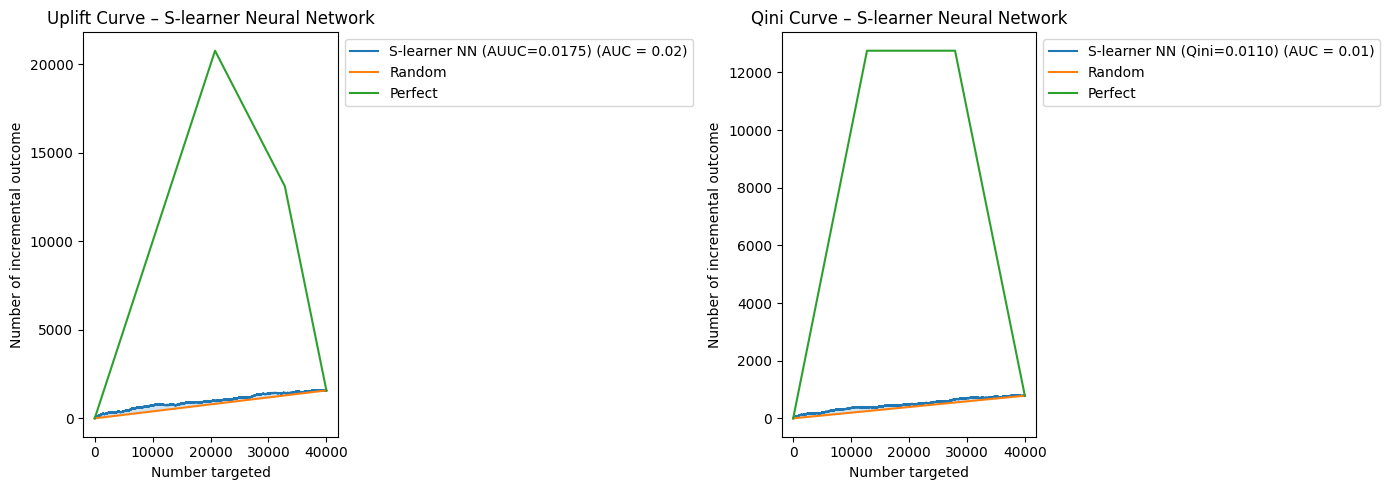

In [43]:
import sklearn.utils

if not hasattr(sklearn.utils, 'check_matplotlib_support'):
    def check_matplotlib_support(caller_name):
        try:
            import matplotlib
        except ImportError:
            raise ImportError(f"Matplotlib is required for {caller_name}")
    sklearn.utils.check_matplotlib_support = check_matplotlib_support

from sklift.viz import plot_uplift_curve, plot_qini_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Uplift curve
plot_uplift_curve(
    y_true=y_test, 
    uplift=uplift_scores, 
    treatment=treatment_test, 
    perfect=True, 
    random=True, 
    name=f"S-learner NN (AUUC={auuc_score:.4f})", 
    ax=axes[0]
)
axes[0].set_title("Uplift Curve – S-learner Neural Network")

# Qini curve
plot_qini_curve(
    y_true=y_test, 
    uplift=uplift_scores, 
    treatment=treatment_test, 
    perfect=True, 
    random=True, 
    name=f"S-learner NN (Qini={qini_score:.4f})", 
    ax=axes[1]
)
axes[1].set_title("Qini Curve – S-learner Neural Network")

plt.tight_layout()
plt.show()